<a href="https://colab.research.google.com/github/nalantishantha/DL_Projects/blob/main/Classification/tf_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [11]:
data = pd.read_csv("sample_data/tf_classification_dataset.csv")

In [12]:
data.shape

(205, 3)

In [13]:
data.describe()

,Height,Weight
count,205.000000,205.000000
mean,160.874125,69.927028
std,15.171040,15.462396
min,123.007006,34.726666
25%,148.942667,58.583137
50%,161.749388,69.544469
75%,172.608090,77.964667
max,199.282251,129.410122


Data Preprocessing

In [14]:
data.head()

,Height,Weight,Sex
0,146.323241,59.861065,Female
1,175.695412,77.863687,Male
2,183.216164,72.131992,Male
3,184.245269,77.546000,Male
4,132.302261,55.188496,Female


In [15]:
data.loc[data['Sex']=='Male', 'Sex']=1
data.loc[data['Sex']=='Female', 'Sex']=0

# data['Sex'] = data['Sex'].map({'Male':1, 'Female':0})

# # one hot encoding using pandas get_dummies() method.
# pd.get_dummies(data, dtype=int)

In [16]:
data.head()

,Height,Weight,Sex
0,146.323241,59.861065,0
1,175.695412,77.863687,1
2,183.216164,72.131992,1
3,184.245269,77.546000,1
4,132.302261,55.188496,0


In [17]:
# get x and y datasets
x = data.drop('Sex', axis=1)
y = data['Sex']

In [18]:
x.head()

,Height,Weight
0,146.323241,59.861065
1,175.695412,77.863687
2,183.216164,72.131992
3,184.245269,77.546000
4,132.302261,55.188496


In [19]:
y.head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [20]:

# feature scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
X = pd.DataFrame(x_scaled, columns=['Height', 'Weight'])

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  205 non-null    float64
 1   Weight  205 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [22]:
y[:5]

,Sex
0,0
1,1
2,1
3,1
4,0


In [23]:
y.dtype

dtype('O')

In [24]:
y = y.astype('int')

In [25]:
y.dtype

dtype('int64')

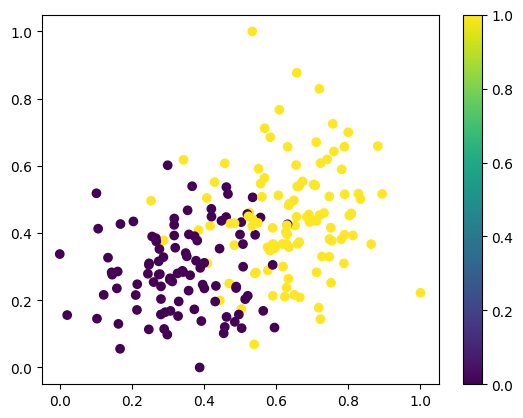

In [26]:
plt.scatter(X['Height'], X['Weight'], c=y)
plt.colorbar()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,  random_state=42)

In [28]:
x.shape, x_train.shape, x_test.shape

((205, 2), (164, 2), (41, 2))

Model building

Option 1 - Use one output node

In [56]:
# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
             optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics = ["accuracy"])

# train the model
epoch_number = 10
history = model.fit(x_train, y_train, epochs=epoch_number)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4878 - loss: 7.7817
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5244 - loss: 1.4072 
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5854 - loss: 1.4120 
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5122 - loss: 1.3134 
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4512 - loss: 1.1145 
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4817 - loss: 0.8443 
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5183 - loss: 0.7998 
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5122 - loss: 0.7438 
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5305 - loss: 0.7598 
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5122 - loss: 0.8046 


In [47]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,261 (126.02 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,508 (84.02 KB)

Model Evaluate

In [48]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5366 - loss: 0.7711 


[0.771067202091217, 0.5365853905677795]

In [49]:
y_pred = model.predict(x_test)

y_pred_classes = (y_pred > 0.5).astype(int)
y_pred_classes[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([[1],
       [1],
       [1],
       [0],
       [1]])

In [50]:
precision = tf.keras.metrics.Precision()
precision.update_state(y_test, y_pred_classes)
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.5135135054588318>

In [51]:
recall = tf.keras.metrics.Recall()
recall.update_state(y_test, y_pred_classes)
recall.result().numpy()

np.float32(0.95)

In [52]:
history.history

{'accuracy': [0.46341463923454285,
  0.48170730471611023,
  0.5182926654815674,
  0.5365853905677795,
  0.49390244483947754,
  0.49390244483947754,
  0.5,
  0.5243902206420898,
  0.5487805008888245,
  0.5792682766914368],
 'loss': [6.154176712036133,
  1.8911302089691162,
  1.0436441898345947,
  1.0971529483795166,
  1.1719228029251099,
  1.1174603700637817,
  1.1814175844192505,
  0.8299643397331238,
  0.7875174283981323,
  0.7283793687820435]}

<Axes: >

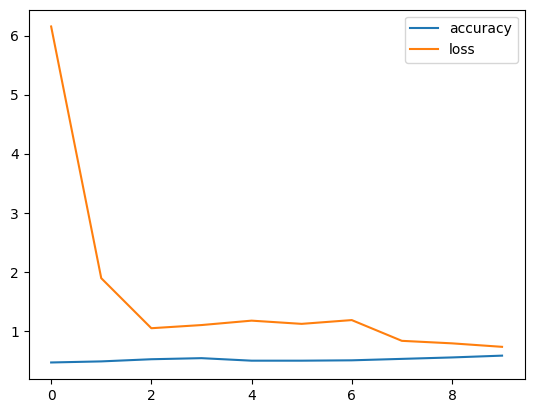

In [53]:
pd.DataFrame(history.history).plot()

Option *2* - Use two output nodes

In [64]:
# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

# compile the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics = ["accuracy"])

# train the model
epoch_number = 10
history = model.fit(x_train, y_train, epochs=epoch_number)

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5244 - loss: 14.6930
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4512 - loss: 2.1822 
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5305 - loss: 1.1545 
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5183 - loss: 1.3551 
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5244 - loss: 0.9417 
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4756 - loss: 0.6950 
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4756 - loss: 0.6958 
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4756 - loss: 0.6957 
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4756 - loss: 0.6954
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4756 - loss: 0.6949 


In [65]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,144 (113.85 KB)

 Trainable params: 9,714 (37.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,430 (75.90 KB)

In [66]:
y_pred = model.predict(x_test)
y_pred[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[0.5101471 , 0.48985294],
       [0.5101471 , 0.48985294],
       [0.5101471 , 0.48985294],
       [0.5101471 , 0.48985294],
       [0.5101471 , 0.48985294]], dtype=float32)

In [63]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)
y_pred[:5]

array([1, 1, 1, 1, 1])